# Red Neuronal

#### Elección de variable: 

Vamos a tomar como la variable objetivo alert, ya que es la única variable categorica

#### Parametrización de los datos

In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.optimize as opt
import math as mt
import matplotlib.pyplot as plt


Input: Corresponde a las 5 características (magnitude, depth, cdi, mmi, sig).

Hidden: Las capas ocultas permiten aprender relaciones no lineales complejas. Se elige un número mayor que la entrada para capturar suficientes patrones.

Output: El problema es de clasificación multiclase (Green, Yellow, Orange, Red), por lo que necesitamos 4 neuronas de salida, una probabilidad por cada color.

In [2]:
input_layer_size = 5 #las cinco clases numericas
hidden_layer_size = 25 #unidades ocultas
num_labels = 4 #numero de clases que puede haber en alert

#### lectura de los datos

A diferencia de la regresión lineal simple que a veces maneja DataFrames, las operaciones de redes neuronales (multiplicación de matrices) en Numpy requieren arrays para ser eficientes, por lo que guardamos los datos en arrays de numpy

In [3]:

def read_file(file_name):
    file = pd.read_csv(file_name)
    X = file[['magnitude','depth','cdi','mmi','sig']].values # .values convierte a matriz NumPy
    y = file[['alert']].values
    return X, y

In [4]:
X, y = read_file('earthquake_alert_balanced_dataset.csv')
print("matriz X: \n", X, "\n")
print("matriz y: \n", y)

matriz X: 
 [[   7.     14.      8.      7.      0.  ]
 [   6.9    25.      4.      4.    -33.  ]
 [   7.    579.      3.      3.    -13.  ]
 ...
 [   7.48  142.      7.      6.    120.  ]
 [   7.04   51.      7.      6.   -115.  ]
 [   6.5     9.      9.      8.    -29.  ]] 

matriz y: 
 [['green']
 ['green']
 ['green']
 ...
 ['yellow']
 ['yellow']
 ['yellow']]


#### Comprobar si hay valores nulos

Los algoritmos matemáticos como la regresión lineal fallan si encuentran valores vacíos (NaN). Verificamos los datos para asegurar que el entrenamiento no se rompa.

In [5]:
full_data= pd.read_csv('earthquake_alert_balanced_dataset.csv')
print("valores nulos por columna:")
print(full_data.isnull().sum())

valores nulos por columna:
magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64


No hay valores nulos que puedan entorpecer el entrenamiento, asi que podemos proceder sin problema

#### Preprocesamiento de los datos

Convertimos las etiquetas de texto a números, ya que es necesario para calcular la matriz de confusión posteriormente

In [6]:
labels_map = {'green': 0, 'yellow': 1, 'orange': 2, 'red': 3}
y_numeric = np.array([labels_map[val[0]] for val in y])

Normalizamos X con media 0 y desviación 1. Esto es obligatorio para redes neuronales, ya que si las entradas tienen escalas muy grandes, al multiplicarse por los pesos, el resultado entra en la función de activación, saturando la función sigmoide y haciendo que el gradiente de casi nulo.Si esto pasa, la red deja de aprender

In [7]:
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)
X_norm = (X - mu) / sigma


Procedemos a dividir los datos en un conjunto de training y un conjunto de test. Es fundamental para evaluar el modelo, ya que si entrenamos y probamos con los mismos datos, el modelo podría memorizar las respuestas. Necesitamos datos nuevos, como los de test, para ver si el modelo funciona correctamente  de forma generalizada, después de haberlos entrenado con el conjunto de train.

Barajamos los datos para eliminar cualquier posibilidad de que los datos estuviesen ordenados.

In [8]:
m = len(y)
indices = np.arange(m)
np.random.shuffle(indices) # Barajar

train_size = int(0.8 * m)
idx_train = indices[:train_size]
idx_test = indices[train_size:]

X_train = X_norm[idx_train]
y_train = y_numeric[idx_train]
X_test = X_norm[idx_test]
y_test = y_numeric[idx_test]

print(f"Datos entrenamiento: {X_train.shape}")
print(f"Datos prueba: {X_test.shape}")

Datos entrenamiento: (1040, 5)
Datos prueba: (260, 5)


#### Unroll de parametros

No podemos iniciar los pesos ($\theta$) en ceros, si todos los pesos fueran iguales, todas las neuronas de la capa oculta aprenderían exactamente lo mismo y la red no sería más poderosa que una regresión simple. El azar asegura que cada neurona se especialice en una característica diferente.

In [9]:
def randInitializeWeights(L_in, L_out):
    epsilon_init = 0.12
    W = np.random.rand(L_out, 1+L_in) * 2 * epsilon_init - epsilon_init
    return W

In [10]:
theta1=randInitializeWeights(input_layer_size, hidden_layer_size)
theta2=randInitializeWeights(hidden_layer_size, num_labels)

Los optimizadores esperan recibir un único vector largo de parámetros, no una lista de matrices. Aplanamos las matrices $\Theta_1$ y $\Theta_2$ en un vector gigante para pasárselo al optimizador. (Unroll)

In [11]:
#Unroll de parametros
nn_params_ini=np.hstack((theta1.ravel(order='F'), theta2.ravel(order='F')))
print("Shapes: ")
print("\tX:", X.shape)
print("\ty:", y.shape)
print("\ttheta1:", theta1.shape)
print("\ttheta2:", theta2.shape)
print("\tparams_ini:", nn_params_ini.shape)

Shapes: 
	X: (1300, 5)
	y: (1300, 1)
	theta1: (25, 6)
	theta2: (4, 26)
	params_ini: (254,)


#### Función coste

Implementamos la función de coste para una red neuronal, nnCostFunctionSinReg sin regularizar

Esta función introduce no linealidad. Sin ella, la red neuronal sería equivalente a una sola regresión lineal gigante. Además, transforma los valores de salida en probabilidades entre 0 y 1.

In [12]:
#Función sigmoide
def sigmoid(z):
    g = 1 / (1+np.exp(-z))
    return g

calculamos el coste (error) de la red neuronal sin aplicar regularización.Elegimos la versión vectorizada de la función porque es mucho más rápida y limpia

In [13]:
def nnCostFunctionSinReg(nn_params, input_layer_size, hidden_layer_size, num_labels, X, y):
    theta1 = np.reshape(a= nn_params[:hidden_layer_size*(input_layer_size+1)], newshape = (hidden_layer_size, input_layer_size+1), order = 'F')
    theta2 = np.reshape(nn_params[hidden_layer_size*(input_layer_size+1):], (num_labels, hidden_layer_size+1), 'F')
    m = len(y)
    suma = 0
    y_d = pd.get_dummies(y.flatten()) # One hot-encoding
    
    a1, a2, h = forward(theta1, theta2, X)
    temp1 = y_d*(np.log(h))
    temp2 = (1-y_d)*(np.log(1-h))
    temp3 = np.sum(temp1+temp2, axis=0)
    J = -(1/m) * np.sum(temp3, axis=0)
    return J


La función forward es el proceso de predicción. Pasamos los datos capa por capa

In [14]:
def forward(theta1, theta2, X):
    ones = np.ones((len(X),1))
    a1 = np.hstack((np.ones((len(X),1)), X))  
    a2 = sigmoid(np.dot(theta1, a1.T))
    a2 = np.hstack((np.ones((len(X),1)), a2.T)) 
    a3 = sigmoid(np.dot(theta2, a2.T))
    a3 = a3.T
    return a1, a2, a3


Procedemos al calculo del coste llamando a la función

In [15]:
J = nnCostFunctionSinReg(nn_params_ini, input_layer_size, hidden_layer_size, num_labels, X, y)
print("Coste de los parámetros: ", J)

Coste de los parámetros:  2.852832318760143


#### GRADIENTE Y COMPROBACION

 Estas funciones se utilizan para comprobar que se ha implementado bien el backpropagation

In [16]:
def computeNumericalGradient(theta, input_layer_size, hidden_layer_size, num_labels,X, y):
    mygrad = np.zeros(theta.size)
    perturb = np.zeros(theta.size)
    myeps = 0.0001
    for i in range(np.size(theta)):
        # Set perturbation vector
        perturb[i] = myeps
        cost_high = nnCostFunctionSinReg(theta + perturb, input_layer_size, hidden_layer_size, num_labels,X, y)
        cost_low = nnCostFunctionSinReg(theta - perturb, input_layer_size, hidden_layer_size, num_labels,X, y)
        # Compute Numerical Gradient
        mygrad[i] = (cost_high - cost_low) / float(2 * myeps)
        perturb[i] = 0
    return mygrad

In [17]:
def debugInitializeWeights(fan_out, fan_in):
    # Set W to zeros
    W = np.zeros((fan_out,1+fan_in))
    # Initialize W using "sin", this ensures that W is always of the same values and will be useful for debugging
    b = np.zeros(W.size)
    for i in np.array(range(1,W.size+1)):
        b[i-1] = mt.sin(i)
    W = np.reshape(b,W.shape,order='F') / 10
    return W

Implementar Backpropagation a mano es propenso a errores matemáticos difíciles de detectar.Comparamos nuestro gradiente con uno calculado a mano. Si la diferencia es menor a $1e-9$, confirmamos que nuestra matemáticas son correctas antes de gastar horas entrenando.

In [18]:
def checkNNGradients(lambda_param):
    input_layer_size = 3
    hidden_layer_size = 5
    num_labels = 3
    m = 5
    #We generate some 'random' test data
    Theta1 = debugInitializeWeights(hidden_layer_size, input_layer_size)
    Theta2 = debugInitializeWeights(num_labels, hidden_layer_size)
    #Reusing debugInitializeWeights to generate X
    X = debugInitializeWeights(m,input_layer_size-1)
    y = np.zeros(m)
    for i in range(m):
        y[i] = (1 + mt.fmod(i+1,num_labels))
    #y = y.T
    # Unroll parameters
    nn_params = np.hstack((Theta1.ravel(order='F'), Theta2.ravel(order='F')))
    #Calculo gradiente por back-propagation
    nn_backprop_params = nnGradFunctionSinReg(nn_params, input_layer_size, hidden_layer_size, num_labels, X, y)
    #Calculo gradiente mediante aproximación numérica
    mygrad = computeNumericalGradient(nn_params, input_layer_size, hidden_layer_size, num_labels,X, y)
    # Visually examine the two gradient computations.  The two columns
    # you get should be very similar.
    df = pd.DataFrame(mygrad,nn_backprop_params)
    

    # Evaluate the norm of the difference between two solutions.
    # If you have a correct implementation, and assuming you used EPSILON = 0.0001
    # in computeNumericalGradient.py, then diff below should be less than 1e-9
    diff = np.linalg.norm((mygrad-nn_backprop_params))/np.linalg.norm((mygrad+nn_backprop_params))

    print('If your backpropagation implementation is correct, then the differences will be small (less than 1e-9):' , diff)

Implementamos la función nnGradFunctionSinReg para que devuelva el gradiente sin regularización. Calcula cuánto contribuyó cada peso individual al error total. Permite culpar a las neuronas específicas y ajustar sus pesos para reducir el error.

In [19]:
def nnGradFunctionSinReg(nn_params, input_layer_size, hidden_layer_size, num_labels, X, y):

    # Recuperar matrices de pesos
    theta1 = np.reshape(
        nn_params[:hidden_layer_size*(input_layer_size+1)],
        (hidden_layer_size, input_layer_size+1),
        order='F'
    )
    theta2 = np.reshape(
        nn_params[hidden_layer_size*(input_layer_size+1):],
        (num_labels, hidden_layer_size+1),
        order='F'
    )

    # One-hot
    y_d = pd.get_dummies(y.flatten()).to_numpy()   # (m, num_labels)

    m = X.shape[0]

    # ---- FORWARD VECTORIAL ----
    a1, a2, a3 = forward(theta1, theta2, X)
    # a1: (m, input+1)
    # a2: (m, hidden+1)
    # a3: (m, num_labels)

    # ---- BACKPROP ----
    delta1 = np.zeros(theta1.shape)
    delta2 = np.zeros(theta2.shape)

    for i in range(m):
        # Extraer activaciones del ejemplo i
        a1_i = a1[i].reshape(1, -1)
        a2_i = a2[i].reshape(1, -1)
        a3_i = a3[i].reshape(1, -1)
        y_i  = y_d[i].reshape(1, -1)

        # Errores
        d3 = a3_i - y_i                                 # (1, num_labels)
        d2 = (theta2[:,1:].T @ d3.T).T * (a2_i[:,1:] * (1 - a2_i[:,1:]))

        # Acumulación
        delta1 += d2.T @ a1_i                           # (hidden, input+1)
        delta2 += d3.T @ a2_i                           # (num_labels, hidden+1)

    # Normalizar
    delta1 /= m
    delta2 /= m

    # Devolver gradientes concatenados
    #print("DELTA 1: ", delta1)
    #print("DELTA 2: ", delta2)
    #print("GRAD\n: ", np.hstack((delta1.ravel(order='F'), delta2.ravel(order='F'))))
    return np.hstack((delta1.ravel(order='F'), delta2.ravel(order='F')))


In [20]:
lambda_param = 0
checkNNGradients(lambda_param)

If your backpropagation implementation is correct, then the differences will be small (less than 1e-9): 2.2425822982665667e-11


#### Entrenamiento de la red neuronal

En el entrenamiento de una red neuronal es importante inicializar aleatoriamente los parámetros theta. Implementaremos la función randInitializeWeights con un épsilon de 0.12.

In [21]:
def randInitializeWeights(L_in, L_out):
    epsilon_init = 0.12
    W = np.random.rand(L_out, 1+L_in) * 2 * epsilon_init - epsilon_init
    return W

In [22]:
print("\nInicializando los parametros de la red neuronal ...\n")
initial_theta1 = randInitializeWeights(input_layer_size, hidden_layer_size)
initial_theta2 = randInitializeWeights(hidden_layer_size, num_labels)
# Unroll parameters (a single column vector)
nn_initial_params = np.hstack((initial_theta1.ravel(order='F'), initial_theta2.ravel(order='F')))
print("\nProceso completado\n")


Inicializando los parametros de la red neuronal ...


Proceso completado



Ya tenemos implementado lo necesario para entrenar la red neuronal. Para un buen conjunto de parámetros, utilizaremos la optimización opt de la librería scipy. 

Configuramos un metodo para guardar el coste:

In [23]:
cost_history = []
def cost_callback(params):
    # Calculamos el coste en cada iteración para guardarlo
    cost = nnCostFunctionSinReg(params, input_layer_size, hidden_layer_size, num_labels, X_train, y_train)
    cost_history.append(cost)

In [24]:
print("Entrenando la red neuronal ...\n")

maxiter = 25

nn_params = opt.fmin_cg(callback=cost_callback,disp=False,maxiter=maxiter, f=nnCostFunctionSinReg, x0=nn_initial_params, fprime=nnGradFunctionSinReg, args=(input_layer_size, hidden_layer_size, num_labels, X_train, y_train))

# Obtain theta1 and theta2 back from nn_params
theta1_final = np.reshape(nn_params[:hidden_layer_size * (input_layer_size + 1)], (hidden_layer_size, input_layer_size + 1), 'F')
theta2_final = np.reshape(nn_params[hidden_layer_size * (input_layer_size + 1):], (num_labels, hidden_layer_size + 1),'F')

Entrenando la red neuronal ...



#### Gráfico de convergencia

Validamos que el optimizador realmente redujo el error en cada iteración.

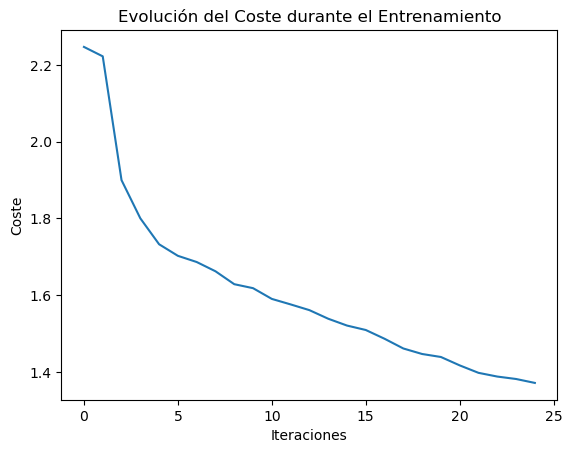

In [25]:
plt.plot(cost_history)
plt.title('Evolución del Coste durante el Entrenamiento')
plt.xlabel('Iteraciones')
plt.ylabel('Coste')
plt.show()

Como vemos, la función está encontrando unos valores para los pesos que hacen que el error entre la predicción de la red y la realidad sea cada vez menor. Este funcionamiento es óptimo y correcto

#### Predicción

Finalmente,vamos a predecir etiquetas implementando la función predict, que devolverá un vector que contenga valores entre 1 y el número de etiquetas posibles.

In [26]:
def predict_indices(theta1, theta2, X):
    m = len(X)
    ones = np.ones((m,1))
    
    # Forward
    a1 = np.hstack((ones, X))
    a2 = sigmoid(np.dot(a1, theta1.T))
    a2 = np.hstack((ones, a2))
    h = sigmoid(np.dot(a2, theta2.T))

    # Devuelve el índice (0, 1, 2, 3) con mayor probabilidad
    return np.argmax(h, axis=1)

In [27]:
# 1. Predecir en el conjunto de TEST
y_pred_test = predict_indices(theta1_final, theta2_final, X_test)

# 2. Calcular Accuracy
accuracy = np.mean(y_pred_test == y_test) * 100
print(f"Tasa de Acierto en Test: {accuracy:.2f}%")

Tasa de Acierto en Test: 68.46%


#### Calculo de la Matriz de Confusión

La matriz nos dice dónde se equivoca la red, ya que la tasa de acierto no nos da toda la información que necesitamos.

definimos una función para el calculo de la misma

In [28]:
def calcular_matriz_confusion(y_real, y_pred, num_clases):
    conf_matrix = np.zeros((num_clases, num_clases), dtype=int)
    for i in range(len(y_real)):
        real = int(y_real[i])
        pred = int(y_pred[i])
        conf_matrix[real, pred] += 1
    return conf_matrix

In [29]:
conf_mat = calcular_matriz_confusion(y_test, y_pred_test, num_labels)

print("\nMatriz de Confusión (Filas: Real, Columnas: Predicción):")
# Etiquetas para que se vea bonito
labels_list = ['green', 'yellow', 'orange', 'red']
df_cm = pd.DataFrame(conf_mat, index=labels_list, columns=labels_list)
print(df_cm)


Matriz de Confusión (Filas: Real, Columnas: Predicción):
        green  yellow  orange  red
green      58       5       2    2
yellow     18      36      17    5
orange      0      12      27   17
red         0       0       4   57


#### Comparación y Análisis de resultados



##### **Resultados obtenidos**

**Tasa de Acierto en el conjunto de prueba:** **68,46%**

**Matriz de Confusión**    
El modelo acierta bien las clases **green** y **red**, donde la diagonal es fuerte.  
La clase **yellow** presenta confusiones con *green* y *orange*.  
La clase **orange** es la más difícil: se confunde con *yellow* y *red*, lo que indica solapamiento entre sus patrones.

---

##### **Comparación de Modelos**

**Regresión Lineal:**  
Se utilizó para predecir una variable numérica, obteniendo un MAPE cercano al **4%**. Es un modelo sencillo y rápido, pero no sirve para clasificación.

**Red Neuronal:**  
Obtiene un **68,46% de acierto** en clasificación. Gracias a su naturaleza no lineal, capta relaciones complejas entre variables como *depth*, *cdi*, *mmi* o *sig*, superando a modelos lineales en tareas de clasificación.

---

##### **Ventajas e Inconvenientes**

**Ventajas de la Red Neuronal**  
- Aprende patrones no lineales complejos.  
- Mejora la capacidad de diferenciación entre clases en problemas con fronteras complejas.

**Inconvenientes de la Red Neuronal**  
- Requiere más cómputo y tiempo de entrenamiento.  
- Sensible a la inicialización y a los hiperparámetros.  
- Necesita normalización o estandarización de forma obligatoria.


